In [4]:
import pandas as pd
import numpy as np
import os
import shutil
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from google.colab import files

# Определяем пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
shutil.move(source_path, destination_path)

# Устанавливаем права доступа
os.chmod(destination_path, 0o600)

# Загружаем файл
uploaded = files.upload()
!kaggle datasets download -d nudratabbas/ai-worker-burnout-and-attrition-risk-dataset

with zipfile.ZipFile('ai-worker-burnout-and-attrition-risk-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('ai-worker-burnout-and-attrition-risk-dataset')

    # Показать файлы в директории
print(os.listdir('ai-worker-burnout-and-attrition-risk-dataset'))

# Загрузка данных

df = pd.read_csv('ai-worker-burnout-and-attrition-risk-dataset/ai_worker_burnout_attrition_2026.csv')

# Просматриваем первые несколько строк датасета
print(df.head())

# Получаем общую информацию о датасете
print(df.info())

# Выводим статистические данные о числовых столбцах
print(df.describe())


# Первичный осмотр
print(df.head())
print(df.info())
print(df.describe())


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset
License(s): CC0-1.0
  0% 0.00/40.7k [00:00<?, ?B/s]
100% 40.7k/40.7k [00:00<00:00, 71.1MB/s]
['ai_worker_burnout_attrition_2026.csv']
  employee_id          job_role  years_experience education_level  country  \
0     EMP0001      Data Analyst                 7             PhD    India   
1     EMP0002   DevOps Engineer                 3     Self-taught   Canada   
2     EMP0003   Prompt Engineer                 3             PhD    India   
3     EMP0004  Backend Engineer                18          Master  Germany   
4     EMP0005     AI Researcher                 5        Bachelor    India   

     industry       company_size remote_work_type  team_size  salary_usd_k  \
0  Healthtech  Large (1000-5000)     Fully Remote          8           184   
1     Fintech  Large (1000-5000)           Hybrid         42            51   
2  Automotive      Startup 

1. Размер исходного датасета: (1500, 21)
2. Используем целевую колонку: 'attrition_risk'
   Первые 5 значений: ['Medium', 'Medium', 'Medium', 'Medium', 'Medium']
   Тип данных: object
3. Преобразуем целевую переменную в числа...
   Уникальные значения: ['Medium' 'Low' 'High']
4. Удалено строк с пропусками: 0
5. Финальный размер датасета: (1500, 21)
6. Размер X: (1500, 20), y: (1500,)
7. Тип y после преобразования: int64
8. Размер обучающей выборки: (1200, 20), тестовой: (300, 20)

Подбор гиперпараметров для Gradient Boosting...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Лучшие параметры для Gradient Boosting:
{'regressor__learning_rate': 0.05, 'regressor__max_depth': 4, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150, 'regressor__subsample': 0.8}
Лучший R² на кросс-валидации: 0.6865

Результаты на тесте (Gradient Boosting tuned):
R² = 0.7186
MAE = 0.1959
MSE = 0.0932

Обучение модели: Linear Regression...

Обучение модели: Decision Tree...

Обучение

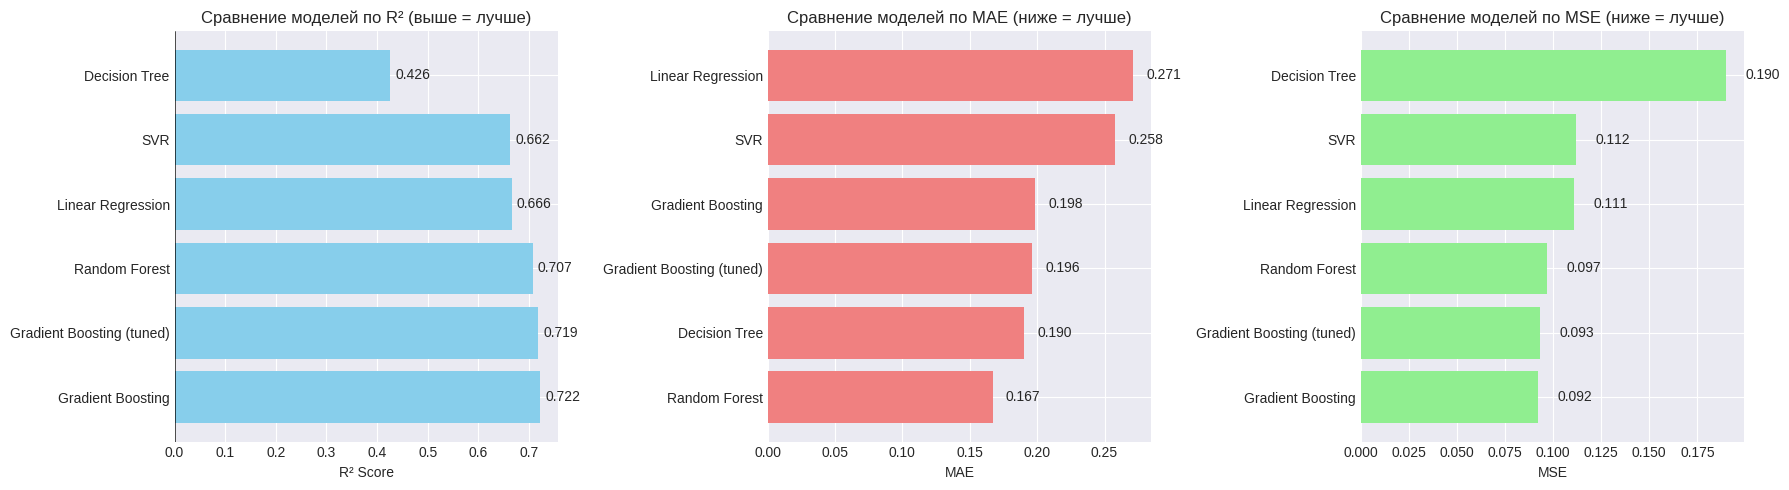

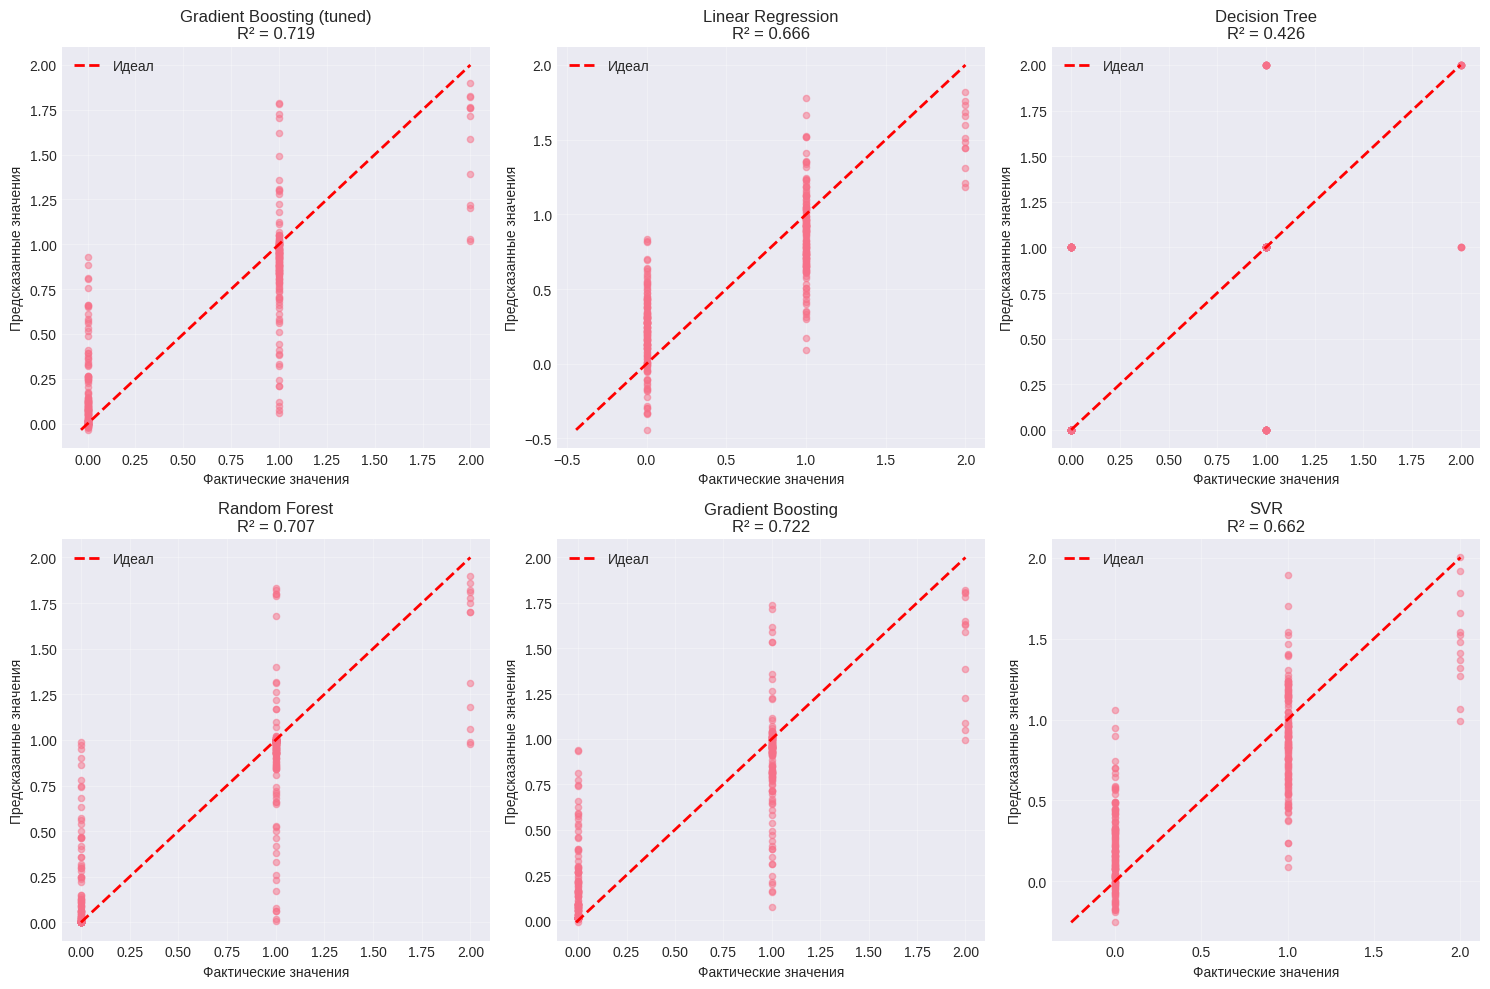

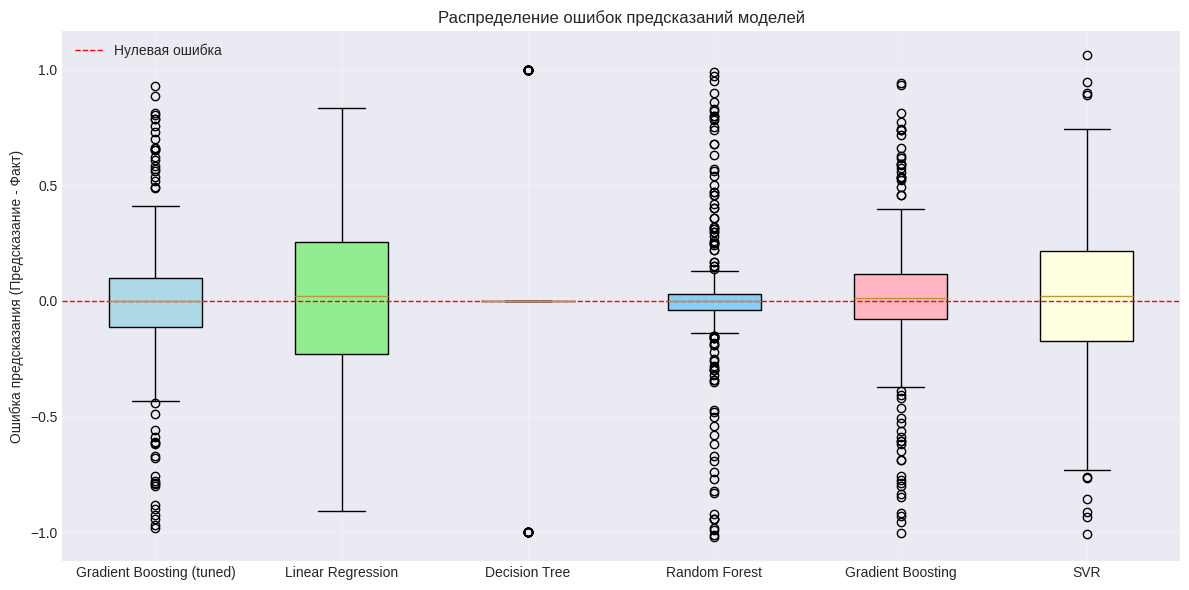

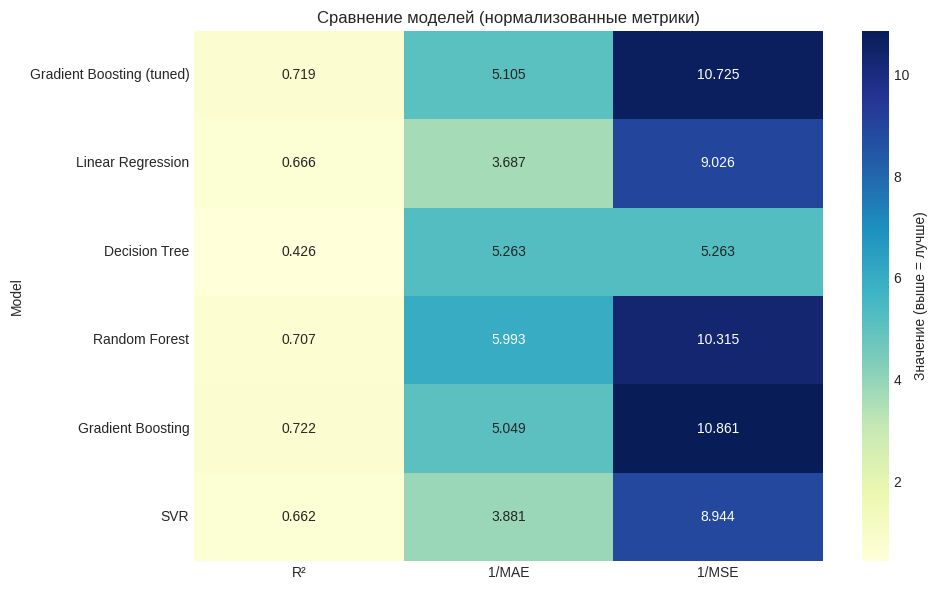

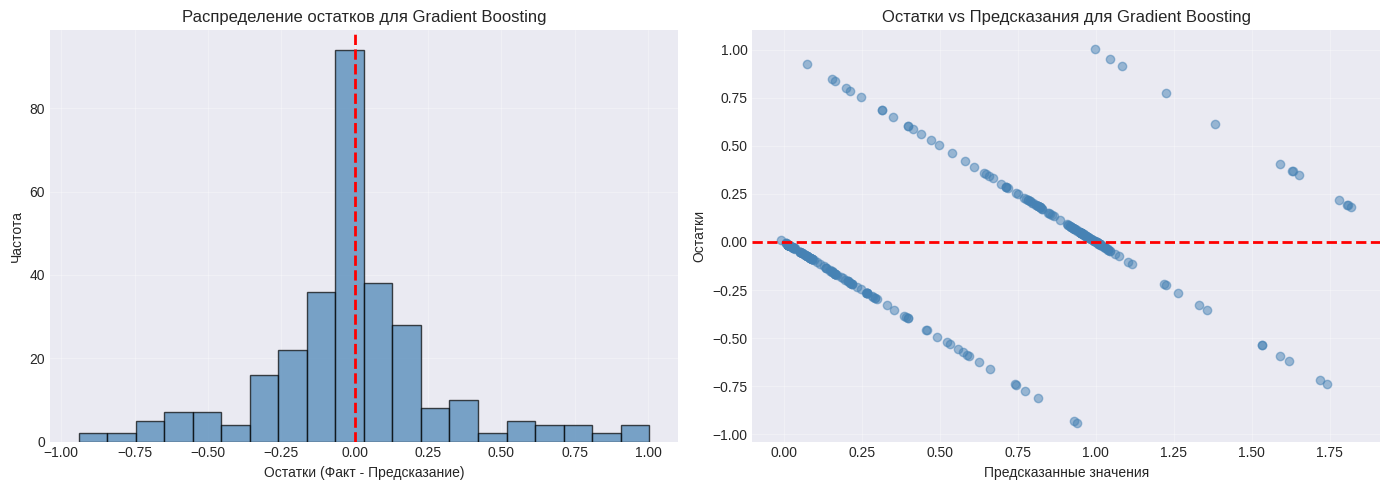

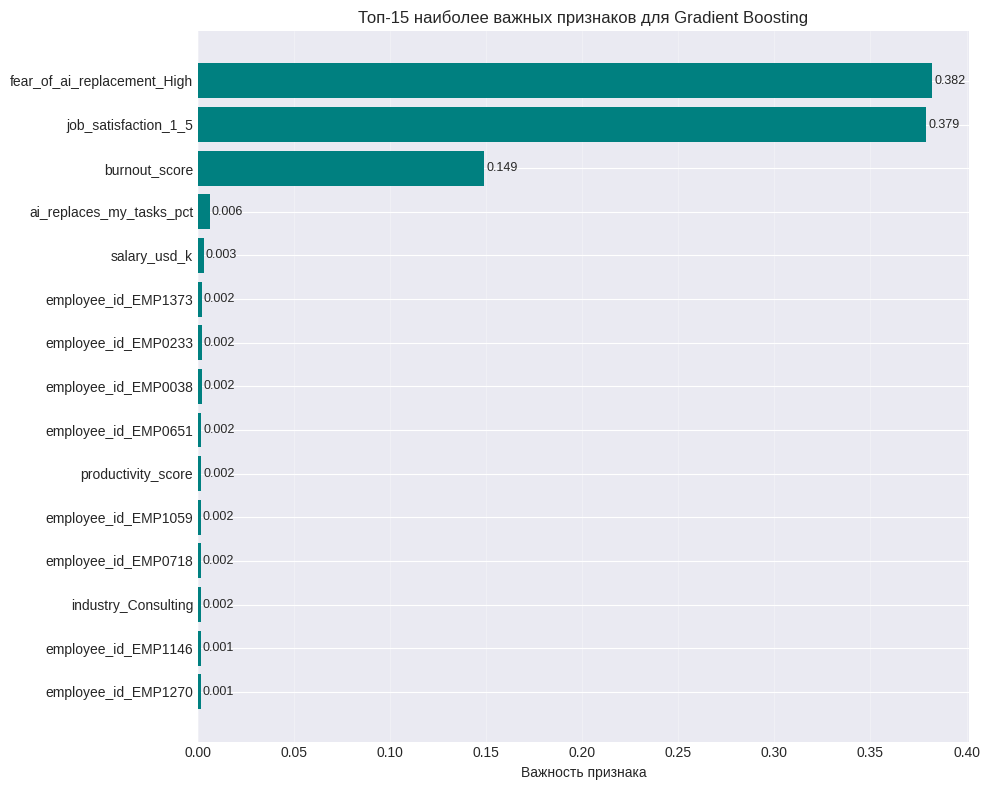


Наиболее важные признаки для предсказания attrition_risk:
  • fear_of_ai_replacement_High: 0.3821
  • job_satisfaction_1_5: 0.3791
  • burnout_score: 0.1489
  • ai_replaces_my_tasks_pct: 0.0060
  • salary_usd_k: 0.0031


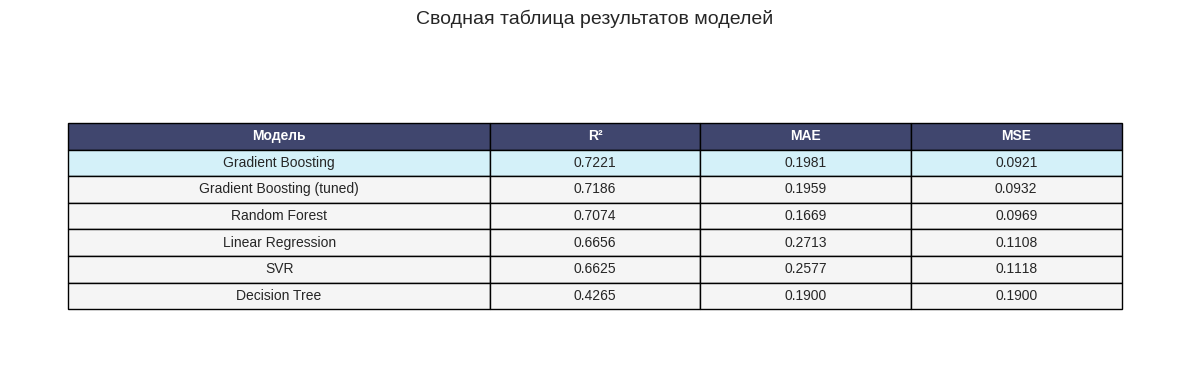


Лучшая модель: Gradient Boosting с R² = 0.7221


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка данных
file_path = 'ai-worker-burnout-and-attrition-risk-dataset.csv'
df = pd.read_csv('ai-worker-burnout-and-attrition-risk-dataset/ai_worker_burnout_attrition_2026.csv')
print(f"1. Размер исходного датасета: {df.shape}")

# Автоматическое определение целевой колонки
possible_targets = ['burnout', 'burnout_rate', 'attrition', 'attrition_risk', 'turnover']
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    # Если не нашли по точному названию, ищем частичное совпадение
    for col in df.columns:
        col_lower = col.lower()
        if 'burnout' in col_lower or 'attrition' in col_lower or 'turnover' in col_lower:
            target_col = col
            break

if target_col is None:
    raise ValueError(f"Не удалось найти целевую колонку. Доступные колонки: {df.columns.tolist()}")

print(f"2. Используем целевую колонку: '{target_col}'")
print(f"   Первые 5 значений: {df[target_col].head().tolist()}")
print(f"   Тип данных: {df[target_col].dtype}")

# Преобразование целевой переменной
if df[target_col].dtype == 'object':
    print("3. Преобразуем целевую переменную в числа...")
    # Проверим, может это категории
    unique_vals = df[target_col].unique()
    print(f"   Уникальные значения: {unique_vals}")

    # Если это ординальные категории
    if set(unique_vals).issubset({'Low', 'Medium', 'High', 'Low ', 'Medium ', 'High '}):
        mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Low ': 0, 'Medium ': 1, 'High ': 2}
        df[target_col] = df[target_col].map(mapping)
    else:
        # Пробуем преобразовать в числа
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

# Удаляем строки с пропусками в целевой переменной
before = len(df)
df = df.dropna(subset=[target_col])
after = len(df)
print(f"4. Удалено строк с пропусками: {before - after}")

if len(df) == 0:
    raise ValueError("Датасет пуст после удаления пропусков! Проверьте данные.")

print(f"5. Финальный размер датасета: {df.shape}")

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"6. Размер X: {X.shape}, y: {y.shape}")
print(f"7. Тип y после преобразования: {y.dtype}")

# Определение типов признаков
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Пайплайн для числовых признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # заполняем пропуски медианой
    ('scaler', StandardScaler())                      # масштабируем
])

# Пайплайн для категориальных признаков
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # заполняем пропуски
    ('onehot', OneHotEncoder(handle_unknown='ignore'))                      # one-hot кодирование
])

# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"8. Размер обучающей выборки: {X_train.shape}, тестовой: {X_test.shape}")

# -----------------------------
# Определение моделей для сравнения
# -----------------------------
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

# Инициализация словарей для сохранения результатов
predictions = {}
models_pipeline = {}

# -----------------------------
# Обучение и оценка
# -----------------------------
results = []

# Сначала выполняем подбор гиперпараметров для Gradient Boosting
print("\nПодбор гиперпараметров для Gradient Boosting...")

# Создаем пайплайн с препроцессором и Gradient Boosting
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Сетка параметров для Gradient Boosting
param_grid_gb = {
    'regressor__n_estimators': [150, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [4, 5],
    'regressor__min_samples_split': [2, 5],
    'regressor__subsample': [0.8]
}

# GridSearch с 5-кратной кросс-валидацией
grid_gb = GridSearchCV(
    gb_pipeline,
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

print("\nЛучшие параметры для Gradient Boosting:")
print(grid_gb.best_params_)
print(f"Лучший R² на кросс-валидации: {grid_gb.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_gb_best = grid_gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb_best)
mae_gb = mean_absolute_error(y_test, y_pred_gb_best)
mse_gb = mean_squared_error(y_test, y_pred_gb_best)

print(f"\nРезультаты на тесте (Gradient Boosting tuned):")
print(f"R² = {r2_gb:.4f}")
print(f"MAE = {mae_gb:.4f}")
print(f"MSE = {mse_gb:.4f}")

# Добавляем результаты tuned Gradient Boosting в общий список
results.append({
    'Model': 'Gradient Boosting (tuned)',
    'MSE': mse_gb,
    'MAE': mae_gb,
    'R2': r2_gb
})

# Сохраняем предсказания для tuned модели
predictions['Gradient Boosting (tuned)'] = y_pred_gb_best
models_pipeline['Gradient Boosting (tuned)'] = grid_gb.best_estimator_

# Теперь обучаем все остальные модели (включая базовый Gradient Boosting для сравнения)
for name, model in models.items():
    print(f"\nОбучение модели: {name}...")

    # Создаём пайплайн с предобработкой и моделью
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    # Обучение
    pipeline.fit(X_train, y_train)

    # Предсказание на тесте
    y_pred = pipeline.predict(X_test)

    # Сохраняем для визуализации
    predictions[name] = y_pred
    models_pipeline[name] = pipeline

    # Расчёт метрик
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    })

# -----------------------------
# Вывод результатов
# -----------------------------
results_df = pd.DataFrame(results)
print("\nСравнение моделей (по убыванию R²):")
print(results_df.sort_values(by='R2', ascending=False).to_string(index=False))

# Определяем лучшую модель по R²
best_model_name = results_df.loc[results_df['R2'].idxmax(), 'Model']
print(f"\n Лучшая модель: {best_model_name} с R² = {results_df['R2'].max():.4f}")

# -----------------------------
# (Опционально) Улучшение лучшей модели через подбор гиперпараметров
# -----------------------------
# Если лучшей оказалась Random Forest, можно выполнить GridSearchCV
if best_model_name == 'Random Forest':
    print("\nВыполняется подбор гиперпараметров для Random Forest...")
    param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5]
    }
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', RandomForestRegressor(random_state=42))])
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший R² на кросс-валидации: {grid_search.best_score_:.4f}")
    # Оценка на тесте
    y_pred_best = grid_search.predict(X_test)
    print(f"R² на тесте после подбора: {r2_score(y_test, y_pred_best):.4f}")

# ==================== ВИЗУАЛИЗАЦИИ ====================

# 1. Сравнение метрик моделей (bar plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² (чем выше, тем лучше)
models_sorted = results_df.sort_values('R2', ascending=False)
axes[0].barh(models_sorted['Model'], models_sorted['R2'], color='skyblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Сравнение моделей по R² (выше = лучше)')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(models_sorted['R2']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# MAE (чем ниже, тем лучше)
models_sorted_mae = results_df.sort_values('MAE')
axes[1].barh(models_sorted_mae['Model'], models_sorted_mae['MAE'], color='lightcoral')
axes[1].set_xlabel('MAE')
axes[1].set_title('Сравнение моделей по MAE (ниже = лучше)')
for i, v in enumerate(models_sorted_mae['MAE']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

# MSE (чем ниже, тем лучше)
models_sorted_mse = results_df.sort_values('MSE')
axes[2].barh(models_sorted_mse['Model'], models_sorted_mse['MSE'], color='lightgreen')
axes[2].set_xlabel('MSE')
axes[2].set_title('Сравнение моделей по MSE (ниже = лучше)')
for i, v in enumerate(models_sorted_mse['MSE']):
    axes[2].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# 2. График "фактические vs предсказанные" для всех моделей
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)

    # Линия идеального предсказания (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеал')

    ax.set_xlabel('Фактические значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{name}\nR² = {results_df[results_df["Model"]==name]["R2"].values[0]:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Удаляем пустой подграфик (если моделей меньше 6)
if len(predictions) < 6:
    for i in range(len(predictions), 6):
        axes[i].remove()

plt.tight_layout()
plt.show()

# 3. Диаграмма размаха (box plot) ошибок предсказаний
fig, ax = plt.subplots(figsize=(12, 6))

errors_data = []
model_names = []
for name, y_pred in predictions.items():
    errors = y_pred - y_test
    errors_data.append(errors)
    model_names.append(name)

bp = ax.boxplot(errors_data, labels=model_names, patch_artist=True)
ax.set_ylabel('Ошибка предсказания (Предсказание - Факт)')
ax.set_title('Распределение ошибок предсказаний моделей')
ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='Нулевая ошибка')
ax.legend()
ax.grid(True, alpha=0.3)

# Раскрашиваем боксплоты
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue', 'lightpink', 'lightyellow']
for patch, color in zip(bp['boxes'], colors[:len(model_names)]):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

# 4. Тепловая карта метрик для наглядного сравнения
fig, ax = plt.subplots(figsize=(10, 6))

# Нормализуем метрики для тепловой карты (чем лучше значение, тем темнее цвет)
metrics_for_heatmap = results_df.set_index('Model')[['R2', 'MAE', 'MSE']].copy()
# Для MAE и MSE инвертируем, чтобы "больше = лучше" для всех метрик
metrics_for_heatmap['MAE_inv'] = 1 / (metrics_for_heatmap['MAE'] + 1e-10)
metrics_for_heatmap['MSE_inv'] = 1 / (metrics_for_heatmap['MSE'] + 1e-10)
metrics_for_heatmap = metrics_for_heatmap[['R2', 'MAE_inv', 'MSE_inv']]
metrics_for_heatmap.columns = ['R²', '1/MAE', '1/MSE']

sns.heatmap(metrics_for_heatmap, annot=True, cmap='YlGnBu', fmt='.3f',
            cbar_kws={'label': 'Значение (выше = лучше)'})
plt.title('Сравнение моделей (нормализованные метрики)')
plt.tight_layout()
plt.show()

# 5. Лучшая модель - анализ остатков
best_model_name = results_df.loc[results_df['R2'].idxmax(), 'Model']
best_y_pred = predictions[best_model_name]
residuals = y_test - best_y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма остатков
axes[0].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Остатки (Факт - Предсказание)')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение остатков для {best_model_name}')
axes[0].grid(True, alpha=0.3)

# График остатков
axes[1].scatter(best_y_pred, residuals, alpha=0.5, color='steelblue')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title(f'Остатки vs Предсказания для {best_model_name}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Анализ важности признаков (для древовидных моделей)
if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree', 'Gradient Boosting (tuned)']:
    # Получаем названия признаков после предобработки
    if categorical_features:
        # Для tuned модели доступ к признакам может отличаться
        if best_model_name == 'Gradient Boosting (tuned)':
            model = models_pipeline[best_model_name]
        else:
            model = models_pipeline[best_model_name]

        feature_names = (numeric_features +
                         list(preprocessor.named_transformers_['cat']
                              .named_steps['onehot']
                              .get_feature_names_out(categorical_features)))
    else:
        feature_names = numeric_features

    # Важности признаков
    if best_model_name == 'Gradient Boosting (tuned)':
        importances = models_pipeline[best_model_name].named_steps['regressor'].feature_importances_
    else:
        importances = models_pipeline[best_model_name].named_steps['regressor'].feature_importances_

    # Сортируем и берём топ-15
    indices = np.argsort(importances)[-15:]

    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=10)
    plt.xlabel('Важность признака')
    plt.title(f'Топ-15 наиболее важных признаков для {best_model_name}')
    plt.grid(True, alpha=0.3, axis='x')

    # Добавляем значения важности
    for i, v in enumerate(importances[indices]):
        plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\nНаиболее важные признаки для предсказания {target_col}:")
    for i in indices[::-1][:5]:  # топ-5 в обратном порядке (от самого важного)
        print(f"  • {feature_names[i]}: {importances[i]:.4f}")

# 7. Итоговый дашборд с ключевыми метриками
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(111)

# Создаём таблицу с результатами
cell_text = []
for idx, row in results_df.sort_values('R2', ascending=False).iterrows():
    cell_text.append([row['Model'], f"{row['R2']:.4f}", f"{row['MAE']:.4f}", f"{row['MSE']:.4f}"])

# Убираем оси
ax.axis('tight')
ax.axis('off')

# Создаём таблицу
table = ax.table(cellText=cell_text,
                 colLabels=['Модель', 'R²', 'MAE', 'MSE'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.3, 0.15, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Выделяем лучшую модель
for (i, j), cell in table.get_celld().items():
    if i == 0:  # заголовок
        cell.set_facecolor('#40466e')
        cell.set_text_props(color='white', weight='bold')
    elif i == 1:  # первая строка (лучшая модель)
        cell.set_facecolor('#d4f1f9')
    else:
        cell.set_facecolor('#f5f5f5')

plt.title('Сводная таблица результатов моделей', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Лучшая модель: {best_model_name} с R² = {results_df['R2'].max():.4f}")
print(f"{'='*50}")